Nandan M  
25MDA083  

21/02/2026

Data Science Lab - DS603

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import plotly.express as px

# Q1

## A)

In [2]:
raw_df = pd.read_csv('exam/Boston_Housing_Q1_Q2 - Copy.csv')

### Understanding dataset and checking data null values

In [3]:
raw_df

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000
1,6.421,9.14,17.8,453600
2,7.185,4.03,17.8,728700
3,6.998,2.94,18.7,701400
4,7.147,5.33,18.7,760200
...,...,...,...,...
484,6.593,9.67,21.0,470400
485,6.120,9.08,21.0,432600
486,6.976,5.64,21.0,501900
487,6.794,6.48,21.0,462000


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   RM       489 non-null    float64
 1   LSTAT    489 non-null    float64
 2   PTRATIO  489 non-null    float64
 3   MEDV     489 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 15.4 KB


In [5]:
raw_df.describe()


,RM,LSTAT,PTRATIO,MEDV
count,489.000000,489.000000,489.000000,4.890000e+02
mean,6.240288,12.939632,18.516564,4.543429e+05
std,0.643650,7.081990,2.111268,1.653403e+05
min,3.561000,1.980000,12.600000,1.050000e+05
25%,5.880000,7.370000,17.400000,3.507000e+05
50%,6.185000,11.690000,19.100000,4.389000e+05
75%,6.575000,17.120000,20.200000,5.187000e+05
max,8.398000,37.970000,22.000000,1.024800e+06


In [6]:
raw_df.isnull().sum()


RM         0
LSTAT      0
PTRATIO    0
MEDV       0
dtype: int64

By observing the data, we can see that there are no null values in the dataset. And also no categorical variables are present in the dataset. So we can directly apply the regression model on the dataset without any preprocessing.

## B) --------------------------------------------------------------

### Correlation Matrix

In [7]:
# MEDV is the target column in modelling.
# dropping the target column 'MEDV' to calculate correlation among features else it will be data leaking.
corr_matrix = raw_df.drop(columns=["MEDV"]).corr()
print(corr_matrix)

               RM     LSTAT   PTRATIO
RM       1.000000 -0.612033 -0.304559
LSTAT   -0.612033  1.000000  0.360445
PTRATIO -0.304559  0.360445  1.000000


In [8]:
# calculating highest correlation pair
# remove self-correlation by masking the diagonal with identity matrix
corr_values = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))

# get max absolute correlation, negative or positive
max_corr = corr_values.abs().stack().idxmax()
max_value = corr_values.loc[max_corr]

print("Highest correlated pair:", max_corr)
print("Correlation value:", max_value)

Highest correlated pair: ('RM', 'LSTAT')
Correlation value: -0.6120332158319393


Above we got higest correlation between RM and LSTAT, with strong negative correlation.

In [9]:
mod_df = raw_df.copy()
mod_df['Interaction_Effect'] = mod_df['RM'] * mod_df['LSTAT']
mod_df

,RM,LSTAT,PTRATIO,MEDV,Interaction_Effect
0,6.575,4.98,15.3,504000,32.74350
1,6.421,9.14,17.8,453600,58.68794
2,7.185,4.03,17.8,728700,28.95555
3,6.998,2.94,18.7,701400,20.57412
4,7.147,5.33,18.7,760200,38.09351
...,...,...,...,...,...
484,6.593,9.67,21.0,470400,63.75431
485,6.120,9.08,21.0,432600,55.56960
486,6.976,5.64,21.0,501900,39.34464
487,6.794,6.48,21.0,462000,44.02512


# Q2

## A) -----------------------------------------------

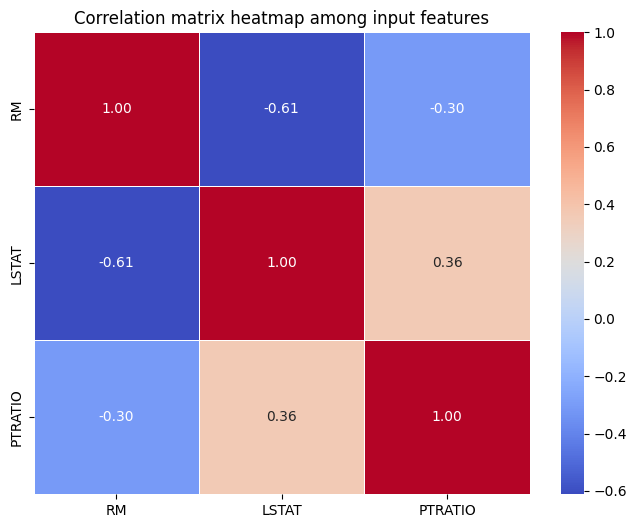

In [10]:
# visualize the correlation matrix using a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,        
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation matrix heatmap among input features")
plt.show()

## B) ----------------------------------------------

In [11]:
# Create price categories (3 equal groups) using qcut
mod_df['Price_Category'] = pd.qcut(mod_df['MEDV'],
                               q=3,
                               labels=['Low', 'Medium', 'High'])

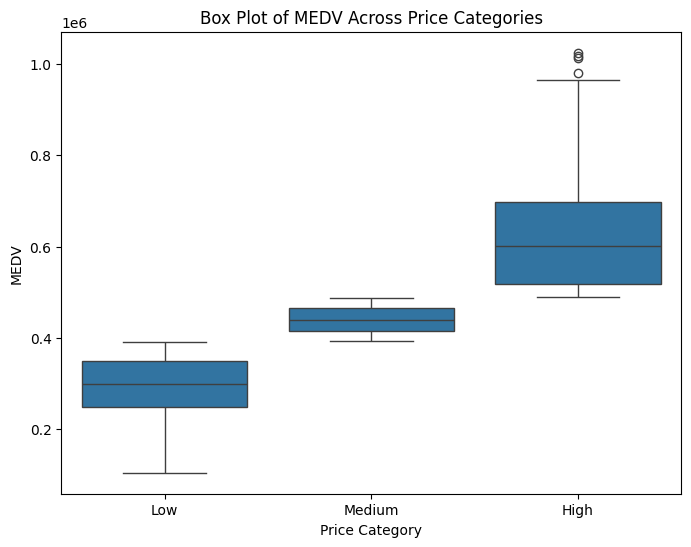

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Price_Category', y='MEDV', data=mod_df)

plt.title("Box Plot of MEDV Across Price Categories")
plt.xlabel("Price Category")
plt.ylabel("MEDV")
plt.show()

In [13]:
# calculating outliers using IQR method for the target variable 'MEDV'
# between 25th and 85th percentile to capture more outliers.
Q1 = mod_df['MEDV'].quantile(0.25)
Q3 = mod_df['MEDV'].quantile(0.85)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers =  mod_df[(mod_df['MEDV'] < lower) | (mod_df['MEDV'] > upper)]

print(outliers)

        RM  LSTAT  PTRATIO     MEDV  Interaction_Effect Price_Category
197  7.853   3.81     14.7  1018500            29.91993           High
253  8.398   5.91     13.0  1024800            49.63218           High


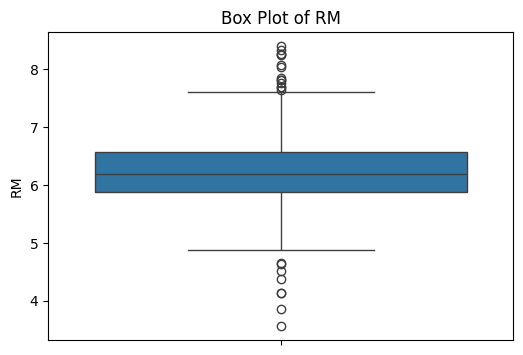

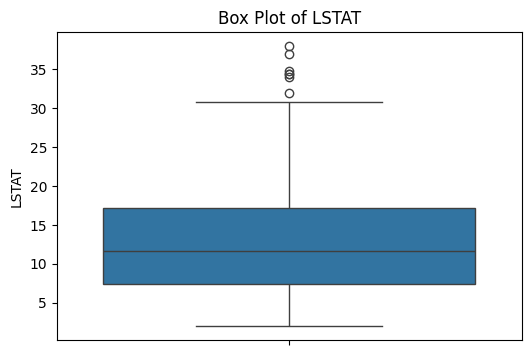

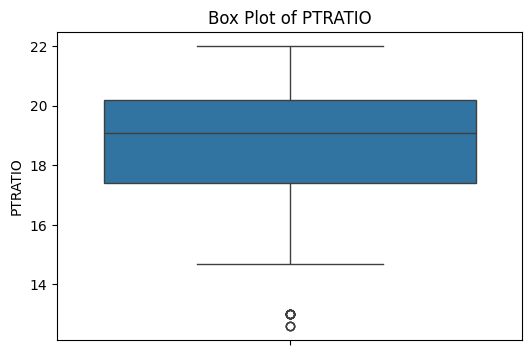

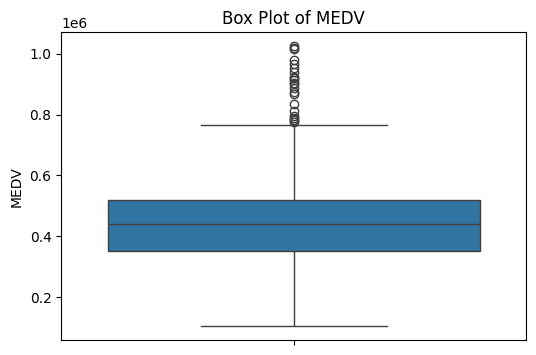

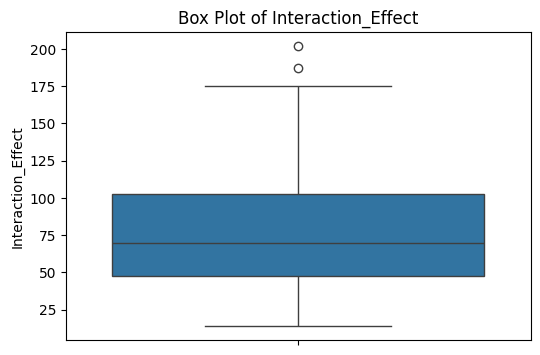

In [14]:
numeric_cols = mod_df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=mod_df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

## C) ----------------------------------------------

In [15]:
# plotting scatter plot of RM vs MEDV colored by Price_Category
fig = px.scatter(
    mod_df,
    x='RM',
    y='MEDV',
    color='Price_Category',
    title="RM vs MEDV (Colored by Price Category)",
    hover_data=['LSTAT', 'PTRATIO']
)

fig.show()

# Q3

## A) -----------------------------------------------

In [16]:
raw_comp_df = pd.read_excel("exam/Q3.xlsx")

In [17]:
raw_comp_df.describe()

,Sample_ID,Time_Reduction_Minutes
count,30.000000,30.000000
mean,15.500000,17.910000
std,8.803408,1.049581
min,1.000000,15.800000
25%,8.250000,17.125000
50%,15.500000,17.950000
75%,22.750000,18.675000
max,30.000000,20.300000


### Based on this data and requirement I will be using one sample t-test to check if the new method has significantly reduced the time taken compared to the claimed mean of 20 minutes.

In [18]:
# Extract the column
data = raw_comp_df["Time_Reduction_Minutes"]

# Claimed mean
claimed_mean = 20

# Perform one-sample t-test
t_statistic, p_value = stats.ttest_1samp(data, claimed_mean)

# Print results
print("Sample Size:", len(data))
print("Sample Mean:", np.mean(data))
print("Sample Std Dev:", np.std(data, ddof=1))
print("t-statistic:", t_statistic)
print("p-value:", p_value)

Sample Size: 30
Sample Mean: 17.91
Sample Std Dev: 1.0495811972664013
t-statistic: -10.90663731560011
p-value: 8.890344468013056e-12


Test Used: One-sample t-test  
Reason: Comparing sample mean with claimed value  

Hypothesis:  
H0: u = 20 (The software reduces processing time by 20 minutes)  
H1: u < 20 (The software reduces processing time by less than 20 minutes)  
alpha = 0.05

Test Statistic: t = -10.9  
p-value: 8.89 x 10e-11  
Decision: Reject H0 (p-value < 0.05)  
Conclusion: The software does not reduce processing time by 20 minutes. The actual reduction is significantly lower.

## B) --------------------------------------------------------------

In [19]:
# Create 3 equal-sized groups using quantiles
raw_comp_df["Group"] = pd.qcut(raw_comp_df["Time_Reduction_Minutes"], 3, labels=["Low", "Medium", "High"])
raw_comp_df

,Sample_ID,Time_Reduction_Minutes,Group
0,1,16.5,Low
1,2,18.2,Medium
2,3,17.1,Low
3,4,19.0,High
4,5,20.3,High
5,6,15.8,Low
6,7,18.7,High
7,8,17.9,Medium
8,9,16.4,Low
9,10,18.6,High


In [20]:
group_low = raw_comp_df[raw_comp_df["Group"] == "Low"]["Time_Reduction_Minutes"]
group_med = raw_comp_df[raw_comp_df["Group"] == "Medium"]["Time_Reduction_Minutes"]
group_high = raw_comp_df[raw_comp_df["Group"] == "High"]["Time_Reduction_Minutes"]


In [21]:
group_low.describe(), group_med.describe(), group_high.describe()

(count    10.000000
 mean     16.730000
 std       0.442342
 min      15.800000
 25%      16.525000
 50%      16.750000
 75%      17.050000
 max      17.300000
 Name: Time_Reduction_Minutes, dtype: float64,
 count    10.000000
 mean     17.950000
 std       0.302765
 min      17.500000
 25%      17.725000
 50%      17.950000
 75%      18.175000
 max      18.400000
 Name: Time_Reduction_Minutes, dtype: float64,
 count    10.00000
 mean     19.05000
 std       0.51908
 min      18.50000
 25%      18.72500
 50%      18.95000
 75%      19.17500
 max      20.30000
 Name: Time_Reduction_Minutes, dtype: float64)

In [22]:
# perform one-way ANOVA
f_statistic, p_value = stats.f_oneway(group_low, group_med, group_high)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

F-statistic: 72.56755138694878
p-value: 1.3777592431937398e-11


Test Used: One-Way ANOVA

F-statistic: 72.57
p-value: 1.38 x 10e-11

At alpha = 0.05:  
p=1.38x10e-11<<0.05

Hence reject H0.

Decision: Reject the null hypothesis.

Conclusion: There is strong statistical evidence that at least one group mean differs significantly from the others.